### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

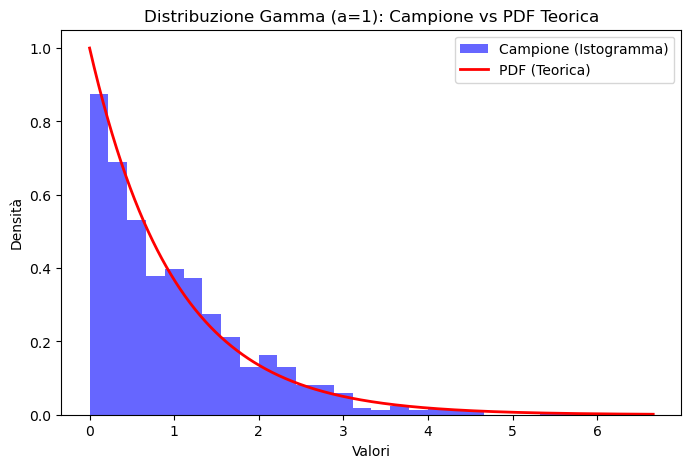

np.float64(1.0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

distr = sp.stats.gamma(a=1)
sample = distr.rvs(1000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sample, bins=30, density=True, alpha=0.6, color='blue', label='Campione (Istogramma)')

x = np.linspace(0, np.max(sample), 1000)
pdf = sp.stats.gamma.pdf(x, a=1)

ax.plot(x, pdf, label='PDF (Teorica)', color='red', linewidth=2)

ax.legend()
plt.title("Distribuzione Gamma (a=1): Campione vs PDF Teorica")
plt.xlabel("Valori")
plt.ylabel("Densità")
plt.show()


#stima campione
sp.stats.gamma.fit(sample)

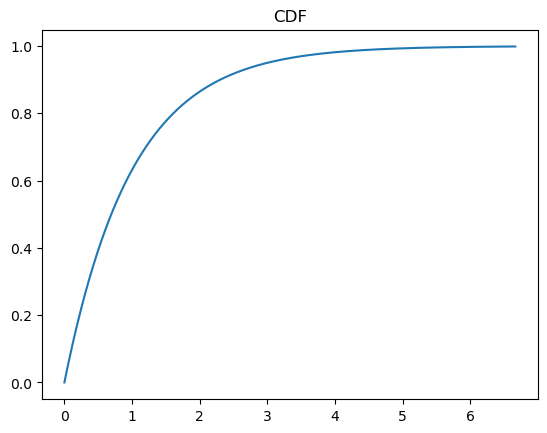

np.float64(1.0)

In [28]:
cdf = sp.stats.gamma.cdf(x, a=1)
plt.plot(x, cdf, label='CDF')
plt.title('CDF')
plt.show()

distr.var()

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

--- TEMPERATURE MASSIME ---
MAE  (Manuale): 1.05 gradi
RMSE (Manuale): 1.19 gradi

--- TEMPERATURE MINIME ---
MAE  (Manuale): 3.19 gradi
RMSE (Manuale): 3.83 gradi


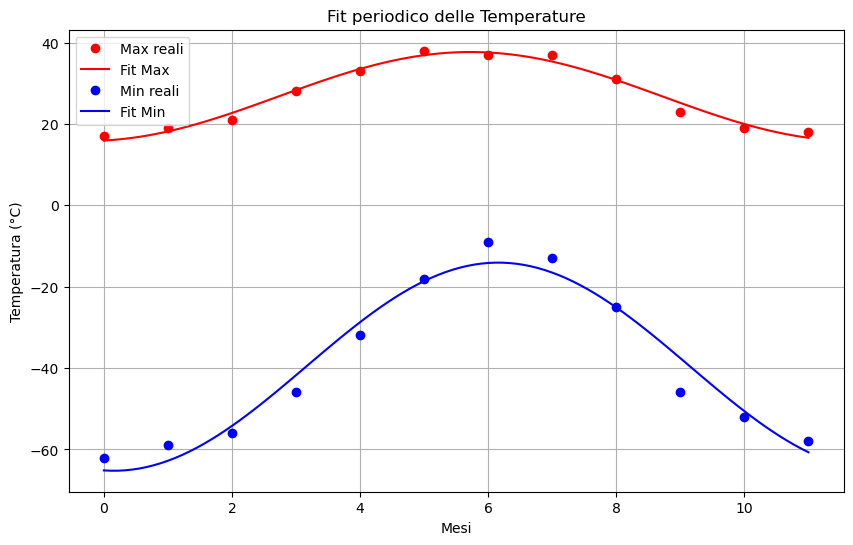

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# 1. I tuoi dati
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
mesi = np.arange(12)

# 2. La nostra funzione periodica
def andamento_annuale(mese, avg, ampl, time_offset):
    return (avg + ampl * np.cos((mese + time_offset) * 2 * np.pi / 12))

# 3. Fitting
res_max, cov_max = optimize.curve_fit(andamento_annuale, mesi, temp_max, [20, 10, 0])
res_min, cov_min = optimize.curve_fit(andamento_annuale, mesi, temp_min, [-40, 20, 0])

# 4. Generiamo i dati della curva (le "previsioni")
pred_max = andamento_annuale(mesi, *res_max)
pred_min = andamento_annuale(mesi, *res_min)

# ==========================================
# 5. CALCOLO MAE E RMSE MANUALE
# ==========================================

# -- Massime --
# Differenza assoluta media
mae_max = np.mean(np.abs(temp_max - pred_max))
# Radice quadrata della media degli errori al quadrato
rmse_max = np.sqrt(np.mean((temp_max - pred_max)**2))

# -- Minime --
mae_min = np.mean(np.abs(temp_min - pred_min))
rmse_min = np.sqrt(np.mean((temp_min - pred_min)**2))

print("--- TEMPERATURE MASSIME ---")
print(f"MAE  (Manuale): {mae_max:.2f} gradi")
print(f"RMSE (Manuale): {rmse_max:.2f} gradi\n")

print("--- TEMPERATURE MINIME ---")
print(f"MAE  (Manuale): {mae_min:.2f} gradi")
print(f"RMSE (Manuale): {rmse_min:.2f} gradi")

# 6. Disegniamo il grafico (rimasto invariato)
mesi_continui = np.linspace(0, 11, 100)
plt.figure(figsize=(10, 6))
plt.plot(mesi, temp_max, 'ro', label='Max reali')
plt.plot(mesi_continui, andamento_annuale(mesi_continui, *res_max), 'r-', label='Fit Max')
plt.plot(mesi, temp_min, 'bo', label='Min reali')
plt.plot(mesi_continui, andamento_annuale(mesi_continui, *res_min), 'b-', label='Fit Min')

plt.title('Fit periodico delle Temperature')
plt.xlabel('Mesi')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [9]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [ ]:
x_train_manual = df['mpg'][::2]
y_train_manual = df['disp'][::2]
x_test_manual = df['mpg'][1::2]
y_test_manual = df['disp'][1::2]

train_model_2 = np.poly1d(np.polyfit(x_train_manual, y_train_manual,2))
train_model_15 = np.poly1d(np.polyfit(x_train_manual, y_train_manual, 15))

y_test_deg2 = train_model_2(x_test_manual)
y_test_deg15 = train_model_15(x_test_manual)

/tmp/ipykernel_3312/1370456933.py:7: RankWarning: Polyfit may be poorly conditioned
  train_model_15 = np.poly1d(np.polyfit(x_train_manual, y_train_manual, 15))


array([ 1.58790497e+02,  1.36062759e+02,  2.15972092e+02,  3.88642394e+04,
        4.09049782e+02,  4.47160873e+02,  2.77816399e+02,  4.71993744e+02,
        8.63973766e+08,  5.58636134e+09,  2.92841972e+02, -1.32024130e+04,
       -1.91636760e+06,  7.57283707e+01,  3.65489334e+02,  1.36062759e+02])